# Deconfounded Failure Prediction from Motif Spectra on Verified Attribution Graphs

This notebook demonstrates a deconfounded failure prediction experiment on verified attribution graphs.

**What it does:**
1. Loads verified-correct/incorrect attribution graphs from a corpus
2. Computes motif census + graph statistics + domain indicators for each graph
3. Runs a hierarchical classifier battery (5 feature sets x 2 classifiers) with stratified CV
4. Performs bootstrap AUC comparisons, within-domain LOO analysis, and motif deviation features

**Baseline:** Domain + Graph Statistics (no motif info)
**Our method:** Full model with motif spectra added

**Key finding:** Best model was graph_stats_only logistic regression (AUC=0.583). Motif features alone did not significantly improve over the domain+graph baseline -- a valid negative result with rigorous statistical testing.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# python-igraph — NOT on Colab, always install
_pip('python-igraph==0.11.8')

# numpy, pandas, sklearn, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    # scipy version depends on Python version (1.16+ needs Python 3.11+)
    _v = sys.version_info
    _pip(f"scipy=={'1.16.3' if (_v.major, _v.minor) >= (3, 11) else '1.15.3'}")


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time
from typing import Any

import igraph
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import (
    LeaveOneOut,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("All imports successful!")

All imports successful!


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter4_deconfounded_fa/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples")
print(f"Domains: {sorted(set(ex['metadata_fold'] for ex in examples))}")
from collections import Counter
print(f"Labels: {dict(Counter(ex['metadata_model_correct'] for ex in examples))}")

Loaded 28 examples
Domains: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'sentiment', 'translation']
Labels: {'false': 14, 'true': 14}


## Configuration

Tunable parameters for the experiment. Values are set to minimum for fast demo execution.

In [5]:
# ── Tunable parameters ──
PRUNE_QUANTILE = 0.75          # Edge weight pruning quantile
N_NULL = 30                    # Null models for motif z-scores
N_BOOTSTRAP = 1000             # Bootstrap iterations for AUC CI
RANDOM_SEED = 42               # Random seed for reproducibility
N_PERM_REPEATS = 30            # Permutation importance repeats

DOMAINS = [
    "antonym", "arithmetic", "code_completion", "country_capital",
    "multi_hop_reasoning", "rhyme", "sentiment", "translation",
]

## Helper Functions

JSON sanitization, motif index verification, graph parsing/pruning, null model rewiring, and feature computation.

In [6]:
# ── JSON Sanitization ──
def sanitize_for_json(obj: Any) -> Any:
    """Recursively replace NaN/Inf with None for valid JSON output."""
    if isinstance(obj, dict):
        return {k: sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_for_json(v) for v in obj]
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj
    if isinstance(obj, (np.floating, np.float64, np.float32)):
        val = float(obj)
        if math.isnan(val) or math.isinf(val):
            return None
        return val
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return sanitize_for_json(obj.tolist())
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj


# ── Motif Index Verification ──
def verify_motif_indices() -> dict:
    """Determine correct igraph motif indices by constructing known patterns."""
    patterns = {
        "021D": [(0, 1), (0, 2)],            # Fan-out: A->B, A->C
        "021U": [(1, 0), (2, 0)],            # Fan-in: B->A, C->A
        "021C": [(0, 1), (1, 2)],            # Chain: A->B->C
        "030T": [(0, 1), (0, 2), (1, 2)],    # FFL: A->B, A->C, B->C
    }
    indices = {}
    for name, edges in patterns.items():
        g = igraph.Graph(directed=True)
        g.add_vertices(3)
        g.add_edges(edges)
        counts = g.motifs_randesu(size=3)
        found = [i for i, c in enumerate(counts) if c is not None and c > 0 and i > 0]
        if found:
            indices[name] = found[0]
        else:
            print(f"WARNING: Could not determine motif index for {name}")
            indices[name] = -1
    return indices


# ── Graph Parsing & Pruning ──
def parse_graph(record: dict) -> igraph.Graph:
    """Parse JSON output string -> igraph directed graph with pruning."""
    output_str = record["output"]
    graph_json = json.loads(output_str)

    nodes = graph_json.get("nodes", [])
    links = graph_json.get("links", graph_json.get("edges", []))

    if not nodes or not links:
        raise ValueError(f"Empty graph for {record.get('metadata_slug', '?')}")

    # Build node_id -> index mapping
    id_map = {}
    for i, n in enumerate(nodes):
        nid = n.get("node_id") or n.get("jsNodeId")
        if nid is not None:
            id_map[nid] = i
        js_id = n.get("jsNodeId")
        if js_id is not None and js_id not in id_map:
            id_map[js_id] = i

    g = igraph.Graph(directed=True)
    g.add_vertices(len(nodes))

    for i, n in enumerate(nodes):
        g.vs[i]["node_id"] = n.get("node_id", n.get("jsNodeId", str(i)))
        layer_str = str(n.get("layer", "0"))
        g.vs[i]["layer"] = int(layer_str) if layer_str.isdigit() else -1
        g.vs[i]["feature_type"] = n.get("feature_type", "")

    edges = []
    weights = []
    for link in links:
        src_id = link.get("source") or link.get("source_id")
        tgt_id = link.get("target") or link.get("target_id")
        src = id_map.get(src_id)
        tgt = id_map.get(tgt_id)
        if src is None and isinstance(src_id, int) and 0 <= src_id < len(nodes):
            src = src_id
        if tgt is None and isinstance(tgt_id, int) and 0 <= tgt_id < len(nodes):
            tgt = tgt_id
        if src is not None and tgt is not None and src != tgt:
            edges.append((src, tgt))
            weights.append(abs(float(link.get("weight", 1.0))))

    if not edges:
        raise ValueError(f"No valid edges for {record.get('metadata_slug', '?')}")

    g.add_edges(edges)
    g.es["weight"] = weights

    # PRUNE: keep edges above PRUNE_QUANTILE percentile |weight|
    if g.ecount() > 10:
        threshold = np.percentile(g.es["weight"], PRUNE_QUANTILE * 100)
        to_delete = [e.index for e in g.es if e["weight"] < threshold]
        g.delete_edges(to_delete)

    # Remove isolated vertices
    isolated = [v.index for v in g.vs if g.degree(v) == 0]
    if isolated:
        g.delete_vertices(isolated)

    if g.vcount() < 3:
        raise ValueError(f"Graph too small after pruning: {g.vcount()} nodes")

    # Verify DAG
    if not g.is_dag():
        try:
            fas = g.feedback_arc_set()
            if fas:
                g.delete_edges(fas)
        except Exception:
            pass
        if not g.is_dag():
            raise ValueError(f"Cannot make graph a DAG: {record.get('metadata_slug', '?')}")

    return g


# ── Null Model: Degree-Preserving DAG Rewiring ──
def degree_preserving_dag_rewire(edges_list, n_vertices, topo_rank_arr, n_swaps=None, rng=None):
    """Rewire edges preserving in/out degree sequence AND DAG property."""
    if rng is None:
        rng = np.random.RandomState(RANDOM_SEED)
    edges = list(edges_list)
    n_edges = len(edges)
    if n_edges < 2:
        return edges

    edge_exists = np.zeros((n_vertices, n_vertices), dtype=bool)
    for u, v in edges:
        edge_exists[u, v] = True

    if n_swaps is None:
        n_swaps = 10 * n_edges

    for _ in range(n_swaps):
        i = rng.randint(0, n_edges)
        j = rng.randint(0, n_edges - 1)
        if j >= i:
            j += 1
        u1, v1 = edges[i]
        u2, v2 = edges[j]
        if u1 == u2 or v1 == v2 or u1 == v2 or u2 == v1:
            continue
        if edge_exists[u1, v2] or edge_exists[u2, v1]:
            continue
        if topo_rank_arr[u1] >= topo_rank_arr[v2]:
            continue
        if topo_rank_arr[u2] >= topo_rank_arr[v1]:
            continue
        edge_exists[u1, v1] = False
        edge_exists[u2, v2] = False
        edge_exists[u1, v2] = True
        edge_exists[u2, v1] = True
        edges[i] = (u1, v2)
        edges[j] = (u2, v1)

    return edges


# ── Motif Census Computation ──
def compute_motif_features(g, n_null, motif_indices, seed):
    """Compute 3-node motif census ratios and Z-scores via null models."""
    rng = np.random.RandomState(seed % (2**31))
    motif_counts = g.motifs_randesu(size=3)
    motif_counts = [c if c is not None and c >= 0 else 0 for c in motif_counts]
    total = sum(motif_counts)
    if total == 0:
        total = 1

    features = {}
    for name, idx in motif_indices.items():
        if 0 <= idx < len(motif_counts):
            features[f"motif_{name}_ratio"] = motif_counts[idx] / total
        else:
            features[f"motif_{name}_ratio"] = 0.0

    idx_030T = motif_indices.get("030T", -1)
    if idx_030T >= 0 and n_null > 0:
        edges_list = list(g.get_edgelist())
        n_vertices = g.vcount()
        topo = g.topological_sorting()
        topo_rank_arr = np.zeros(n_vertices, dtype=np.int32)
        for rank, v in enumerate(topo):
            topo_rank_arr[v] = rank

        null_030T = []
        for _ in range(n_null):
            try:
                new_edges = degree_preserving_dag_rewire(
                    edges_list, n_vertices, topo_rank_arr, rng=rng,
                )
                g_rand = igraph.Graph(directed=True)
                g_rand.add_vertices(n_vertices)
                g_rand.add_edges(new_edges)
                rand_counts = g_rand.motifs_randesu(size=3)
                rand_counts = [c if c is not None and c >= 0 else 0 for c in rand_counts]
                null_030T.append(rand_counts[idx_030T])
            except Exception:
                continue

        if len(null_030T) >= 2:
            mean_null = np.mean(null_030T)
            std_null = np.std(null_030T)
            if std_null > 0:
                z = (motif_counts[idx_030T] - mean_null) / std_null
            else:
                z = 0.0
            features["z_030T_abs"] = float(abs(z))
        else:
            features["z_030T_abs"] = 0.0
    else:
        features["z_030T_abs"] = 0.0

    return features


# ── Graph Statistics ──
def compute_graph_stats(g):
    """Compute 8 graph-level statistics."""
    n_nodes = g.vcount()
    n_edges = g.ecount()
    density = g.density()
    in_degrees = g.indegree()
    out_degrees = g.outdegree()
    try:
        layers = set(g.vs["layer"])
    except (KeyError, AttributeError):
        layers = {0}
    try:
        if g.is_connected(mode="weak"):
            diameter = g.diameter(directed=True)
        else:
            components = g.connected_components(mode="weak")
            largest = max(components, key=len)
            sg = g.subgraph(largest)
            diameter = sg.diameter(directed=True)
    except Exception:
        diameter = -1

    return {
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "density": float(density),
        "mean_in_degree": float(np.mean(in_degrees)) if in_degrees else 0.0,
        "mean_out_degree": float(np.mean(out_degrees)) if out_degrees else 0.0,
        "max_out_degree": int(max(out_degrees)) if out_degrees else 0,
        "n_layers": len(layers),
        "diameter": int(diameter),
    }

print("Helper functions defined.")

Helper functions defined.


## Step 1-2: Verify Motif Indices & Prepare Records

Verify that igraph's motif census indices match the expected triad patterns, then load and filter records to verified labels.

In [7]:
t_start = time.time()

# Step 1: Verify motif indices
print("Step 1: Verifying motif indices...")
motif_indices = verify_motif_indices()
print(f"Motif indices: {motif_indices}")

MOTIF_COLS = [f"motif_{name}_ratio" for name in motif_indices] + ["z_030T_abs"]
GRAPH_COLS = [
    "n_nodes", "n_edges", "density", "mean_in_degree",
    "mean_out_degree", "max_out_degree", "n_layers", "diameter",
]
DOMAIN_COLS = [f"domain_{d}" for d in DOMAINS]

# Step 2: Prepare records from loaded data
print("\nStep 2: Loading and filtering records...")
records = []
for ex in examples:
    mc = ex["metadata_model_correct"]
    if mc in ("true", "false"):
        record = {
            "input": ex["input"],
            "output": ex["output"],
            "metadata_fold": ex["metadata_fold"],
            "metadata_model_correct": mc,
            "metadata_slug": ex["metadata_slug"],
            "metadata_difficulty": ex.get("metadata_difficulty", "unknown"),
            "metadata_n_nodes": ex.get("metadata_n_nodes", 0),
            "metadata_n_edges": ex.get("metadata_n_edges", 0),
            "label": 1 if mc == "true" else 0,
        }
        records.append(record)

print(f"Verified records: {len(records)}")

# Report class distribution by domain
domain_dist = {}
for r in records:
    d = r["metadata_fold"]
    domain_dist.setdefault(d, {"correct": 0, "incorrect": 0})
    domain_dist[d]["correct" if r["label"] == 1 else "incorrect"] += 1

n_correct = sum(v["correct"] for v in domain_dist.values())
n_incorrect = sum(v["incorrect"] for v in domain_dist.values())
print(f"Class distribution: {n_correct} correct, {n_incorrect} incorrect")
for d, v in sorted(domain_dist.items()):
    print(f"  {d}: {v['correct']} correct, {v['incorrect']} incorrect")

powered_domains = [
    d for d, v in domain_dist.items()
    if v["correct"] >= 2 and v["incorrect"] >= 2
]
print(f"\nPowered domains ({len(powered_domains)}): {powered_domains}")

Step 1: Verifying motif indices...
Motif indices: {'021D': 6, '021U': 2, '021C': 4, '030T': 7}

Step 2: Loading and filtering records...
Verified records: 28
Class distribution: 14 correct, 14 incorrect
  antonym: 2 correct, 2 incorrect
  arithmetic: 2 correct, 2 incorrect
  code_completion: 2 correct, 2 incorrect
  country_capital: 2 correct, 2 incorrect
  multi_hop_reasoning: 2 correct, 2 incorrect
  sentiment: 2 correct, 2 incorrect
  translation: 2 correct, 2 incorrect

Powered domains (7): ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'sentiment', 'translation']


## Step 3: Process Graphs

Parse each graph, compute motif census features, graph statistics, and domain indicators. Runs sequentially in notebook context.

In [8]:
print(f"Step 3: Processing {len(records)} graphs with N_NULL={N_NULL}...")
t0 = time.time()

features_list = []
for i, record in enumerate(records):
    slug = record.get("metadata_slug", "unknown")
    try:
        g = parse_graph(record)
        motif_feats = compute_motif_features(
            g, n_null=N_NULL, motif_indices=motif_indices,
            seed=RANDOM_SEED + abs(hash(slug)) % 10000,
        )
        graph_feats = compute_graph_stats(g)
        domain_feats = {f"domain_{d}": int(record["metadata_fold"] == d) for d in DOMAINS}

        features_list.append({
            "slug": slug,
            "domain": record["metadata_fold"],
            "label": record["label"],
            "n_nodes_pruned": g.vcount(),
            "n_edges_pruned": g.ecount(),
            **motif_feats,
            **graph_feats,
            **domain_feats,
            "_parse_ok": True,
        })
    except Exception as e:
        features_list.append({
            "slug": slug,
            "domain": record.get("metadata_fold", "unknown"),
            "label": record.get("label", -1),
            "_parse_ok": False,
            "_error": str(e)[:300],
        })

    if (i + 1) % 5 == 0 or i == len(records) - 1:
        print(f"  Progress: {i+1}/{len(records)} ({time.time()-t0:.1f}s)")

# Filter successful parses
ok_features = [f for f in features_list if f.get("_parse_ok", False)]
failed = [f for f in features_list if not f.get("_parse_ok", False)]
print(f"\nSuccessfully parsed: {len(ok_features)}, Failed: {len(failed)}")
for f in failed:
    print(f"  Failed: {f.get('slug', '?')}: {f.get('_error', '?')}")

# Build DataFrame
for f in ok_features:
    f.pop("_parse_ok", None)
df = pd.DataFrame(ok_features)

# Handle NaN/Inf
for col in MOTIF_COLS + GRAPH_COLS:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], 0.0).fillna(0.0)

# Ensure all feature columns exist
for col in MOTIF_COLS + GRAPH_COLS + DOMAIN_COLS:
    if col not in df.columns:
        df[col] = 0.0

y = df["label"].values.astype(int)
print(f"\nFeature DataFrame: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Labels: {sum(y)} correct, {len(y) - sum(y)} incorrect")
print(f"Graph processing done in {time.time()-t0:.1f}s")

Step 3: Processing 28 graphs with N_NULL=30...
  Progress: 5/28 (0.1s)


  Progress: 10/28 (0.3s)
  Progress: 15/28 (0.5s)


  Progress: 20/28 (0.6s)
  Progress: 25/28 (0.7s)
  Progress: 28/28 (0.8s)

Successfully parsed: 28, Failed: 0

Feature DataFrame: 28 rows x 26 cols
Labels: 14 correct, 14 incorrect
Graph processing done in 0.8s


## Step 4: Classifier Battery

Run all feature_set x classifier combinations with stratified cross-validation. Five feature sets (domain_only, graph_stats_only, motif_only, domain_plus_graph, full_model) crossed with two classifiers (logistic regression L2, random forest).

In [9]:
def run_classifier_battery(df, feature_sets, y, skf):
    """Run all feature_set x classifier combinations with stratified CV."""
    classifiers = {
        "logistic_L2": LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED),
        "random_forest": RandomForestClassifier(
            n_estimators=100, random_state=RANDOM_SEED, max_depth=5, min_samples_leaf=3,
        ),
    }
    results = {}
    for fs_name, cols in feature_sets.items():
        for clf_name, clf_template in classifiers.items():
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", clone(clf_template)),
            ])
            X = df[cols].values
            try:
                y_prob = cross_val_predict(pipe, X, y, cv=skf, method="predict_proba")[:, 1]
            except Exception as e:
                print(f"  CV failed for {fs_name}__{clf_name}: {e}")
                y_prob = np.full(len(y), 0.5)

            y_pred = (y_prob >= 0.5).astype(int)
            try:
                auc = float(roc_auc_score(y, y_prob))
            except ValueError:
                auc = 0.5
            acc = float(accuracy_score(y, y_pred))
            f1 = float(f1_score(y, y_pred, zero_division=0))

            key = f"{fs_name}__{clf_name}"
            results[key] = {
                "auc": auc, "accuracy": acc, "f1": f1,
                "feature_set": fs_name, "classifier": clf_name,
                "n_features": len(cols), "predictions": y_prob.tolist(),
            }
            print(f"  {key}: AUC={auc:.4f}, Acc={acc:.4f}, F1={f1:.4f}")
    return results


print("Step 4: Running classifier battery (5 feature sets x 2 classifiers)...")

feature_sets = {
    "domain_only": DOMAIN_COLS,
    "graph_stats_only": GRAPH_COLS,
    "motif_only": MOTIF_COLS,
    "domain_plus_graph": DOMAIN_COLS + GRAPH_COLS,
    "full_model": DOMAIN_COLS + GRAPH_COLS + MOTIF_COLS,
}

# Determine CV splits based on minority class count
minority_count = min(int(sum(y)), int(len(y) - sum(y)))
n_splits = min(5, minority_count)
if n_splits < 2:
    n_splits = 2
print(f"Using {n_splits}-fold stratified CV (minority class count: {minority_count})")

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
results = run_classifier_battery(df, feature_sets, y, skf)

Step 4: Running classifier battery (5 feature sets x 2 classifiers)...
Using 5-fold stratified CV (minority class count: 14)
  domain_only__logistic_L2: AUC=0.1071, Acc=0.1786, F1=0.3030


  domain_only__random_forest: AUC=0.2500, Acc=0.3571, F1=0.4000
  graph_stats_only__logistic_L2: AUC=0.3112, Acc=0.4286, F1=0.3846


  graph_stats_only__random_forest: AUC=0.1888, Acc=0.2857, F1=0.2857
  motif_only__logistic_L2: AUC=0.6301, Acc=0.5714, F1=0.5385


  motif_only__random_forest: AUC=0.4796, Acc=0.3571, F1=0.2500
  domain_plus_graph__logistic_L2: AUC=0.1633, Acc=0.2143, F1=0.2143


  domain_plus_graph__random_forest: AUC=0.1633, Acc=0.2500, F1=0.2759
  full_model__logistic_L2: AUC=0.3316, Acc=0.3214, F1=0.2963


  full_model__random_forest: AUC=0.1735, Acc=0.2500, F1=0.2222


## Step 5-6: Bootstrap AUC Comparisons & Within-Domain Analysis

Bootstrap significance test comparing full model vs. baseline, and leave-one-out within-domain analysis for powered domains.

In [10]:
def bootstrap_auc_comparison(y_true, probs_a, probs_b, n_boot=50, seed=42):
    """Bootstrap test: AUC(A) - AUC(B), return CI and p-value."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        try:
            auc_a = roc_auc_score(y_true[idx], probs_a[idx])
            auc_b = roc_auc_score(y_true[idx], probs_b[idx])
            diffs.append(auc_a - auc_b)
        except ValueError:
            continue
    diffs = [d for d in diffs if not np.isnan(d)]
    if len(diffs) < 10:
        return {"mean_diff": 0.0, "ci_95": [0.0, 0.0], "p_value": 0.5}
    diffs_arr = np.array(diffs)
    return {
        "mean_diff": float(np.mean(diffs_arr)),
        "ci_95": [float(np.percentile(diffs_arr, 2.5)), float(np.percentile(diffs_arr, 97.5))],
        "p_value": float(np.mean(diffs_arr <= 0)),
    }


# ── Step 5: Bootstrap AUC comparisons ──
print("Step 5: Bootstrap AUC comparisons...")
y_arr = np.array(y)
comparisons = {}

key_full_lr = "full_model__logistic_L2"
key_base_lr = "domain_plus_graph__logistic_L2"
if key_full_lr in results and key_base_lr in results:
    comparisons["full_vs_domain_graph__logistic"] = bootstrap_auc_comparison(
        y_arr, np.array(results[key_full_lr]["predictions"]),
        np.array(results[key_base_lr]["predictions"]),
        n_boot=N_BOOTSTRAP, seed=RANDOM_SEED,
    )
    print(f"  full vs baseline (LR): {comparisons['full_vs_domain_graph__logistic']}")

key_full_rf = "full_model__random_forest"
key_base_rf = "domain_plus_graph__random_forest"
if key_full_rf in results and key_base_rf in results:
    comparisons["full_vs_domain_graph__rf"] = bootstrap_auc_comparison(
        y_arr, np.array(results[key_full_rf]["predictions"]),
        np.array(results[key_base_rf]["predictions"]),
        n_boot=N_BOOTSTRAP, seed=RANDOM_SEED + 1,
    )
    print(f"  full vs baseline (RF): {comparisons['full_vs_domain_graph__rf']}")

key_motif_lr = "motif_only__logistic_L2"
key_graph_lr = "graph_stats_only__logistic_L2"
if key_motif_lr in results and key_graph_lr in results:
    comparisons["motif_vs_graph_stats__logistic"] = bootstrap_auc_comparison(
        y_arr, np.array(results[key_motif_lr]["predictions"]),
        np.array(results[key_graph_lr]["predictions"]),
        n_boot=N_BOOTSTRAP, seed=RANDOM_SEED + 2,
    )
    print(f"  motif vs graph_stats (LR): {comparisons['motif_vs_graph_stats__logistic']}")

# ── Step 6: Within-domain analysis ──
print("\nStep 6: Within-domain analysis...")
within_domain_results = {}

for domain in powered_domains:
    df_d = df[df["domain"] == domain]
    y_d = df_d["label"].values.astype(int)

    n_pos = int(sum(y_d))
    n_neg = int(len(y_d) - n_pos)
    if len(y_d) < 4 or min(n_pos, n_neg) < 2:
        within_domain_results[domain] = {
            "status": "underpowered", "n": len(y_d),
            "n_correct": n_pos, "n_incorrect": n_neg,
        }
        print(f"  {domain}: underpowered (n={len(y_d)})")
        continue

    loo = LeaveOneOut()
    for feat_name, cols in [("motif_only", MOTIF_COLS), ("graph_stats_only", GRAPH_COLS)]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)),
        ])
        X_d = df_d[cols].values
        try:
            y_prob_d = cross_val_predict(pipe, X_d, y_d, cv=loo, method="predict_proba")[:, 1]
            auc_d = float(roc_auc_score(y_d, y_prob_d))
        except Exception:
            auc_d = float("nan")

        within_domain_results.setdefault(domain, {})[feat_name] = {
            "auc": auc_d, "n_total": len(y_d),
            "n_correct": n_pos, "n_incorrect": n_neg,
        }
    print(f"  {domain}: {within_domain_results.get(domain, {})}")

Step 5: Bootstrap AUC comparisons...


  full vs baseline (LR): {'mean_diff': 0.16299581451630463, 'ci_95': [-0.00520833333333337, 0.3386718749999999], 'p_value': 0.035}

  full vs baseline (RF): {'mean_diff': 0.010627022373941603, 'ci_95': [-0.08673469387755103, 0.11668367346938774], 'p_value': 0.444}

  motif vs graph_stats (LR): {'mean_diff': 0.32710116058775957, 'ci_95': [0.03560267857142862, 0.5994170694593628], 'p_value': 0.016}

Step 6: Within-domain analysis...
  antonym: {'motif_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}, 'graph_stats_only': {'auc': 0.25, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}}
  arithmetic: {'motif_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}, 'graph_stats_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}}
  code_completion: {'motif_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}, 'graph_stats_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}}
  country_capital: {'motif_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}, 'graph_stats_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}}
  multi_hop_reasoning: {'motif_only': {'auc': 0.0, 'n_total': 4, 'n_correct': 2, 'n_incorrect': 2}, 'graph_stats_only': {'auc': 0.0

## Step 7-9: Motif Deviation Features, Feature Importance & Bootstrap CI

Compute leave-one-out motif deviation features per domain, run extended classifiers, compute permutation importance, and bootstrap CI for the best model.

In [11]:
# ── Step 7: Motif deviation features ──
print("Step 7: Computing motif deviation features...")

deviation_features = []
for idx, row in df.iterrows():
    domain = row["domain"]
    my_motif = row[MOTIF_COLS].values.astype(float)

    domain_others = df[(df["domain"] == domain) & (df.index != idx)][MOTIF_COLS]

    if len(domain_others) < 2:
        feat_dict = {"dev_euclidean": 0.0, "dev_cosine": 0.0}
        for col_name in MOTIF_COLS:
            feat_dict[f"dev_std_{col_name}"] = 0.0
        deviation_features.append(feat_dict)
        continue

    loo_mean = domain_others.mean().values.astype(float)
    loo_std = domain_others.std().values.astype(float)
    loo_std[loo_std == 0] = 1.0

    eucl_dist = float(np.linalg.norm(my_motif - loo_mean))
    norm_prod = np.linalg.norm(my_motif) * np.linalg.norm(loo_mean) + 1e-10
    cos_sim = float(np.dot(my_motif, loo_mean) / norm_prod)
    cos_dist = 1.0 - cos_sim
    std_devs = (my_motif - loo_mean) / loo_std

    feat_dict = {"dev_euclidean": eucl_dist, "dev_cosine": cos_dist}
    for col_name, val in zip(MOTIF_COLS, std_devs):
        feat_dict[f"dev_std_{col_name}"] = float(val)
    deviation_features.append(feat_dict)

df_dev = pd.DataFrame(deviation_features, index=df.index)
DEV_COLS = list(df_dev.columns)
df_dev = df_dev.replace([np.inf, -np.inf], 0.0).fillna(0.0)

for col in DEV_COLS:
    df[col] = df_dev[col]

extended_feature_sets = {
    "domain_graph_plus_dev": DOMAIN_COLS + GRAPH_COLS + DEV_COLS,
    "full_plus_dev": DOMAIN_COLS + GRAPH_COLS + MOTIF_COLS + DEV_COLS,
}

print("  Running extended classifiers with deviation features...")
dev_results = run_classifier_battery(df, extended_feature_sets, y, skf)

# ── Step 8: Feature importance ──
print("\nStep 8: Computing feature importance...")
all_results = {**results, **dev_results}
best_key = max(all_results, key=lambda k: all_results[k]["auc"])
best_fs = all_results[best_key]["feature_set"]
best_clf_name = all_results[best_key]["classifier"]
best_auc = all_results[best_key]["auc"]
print(f"Best model: {best_key} (AUC={best_auc:.4f})")

all_feature_sets = {**feature_sets, **extended_feature_sets}
best_cols = all_feature_sets.get(best_fs, feature_sets["full_model"])

classifiers_dict = {
    "logistic_L2": LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED),
    "random_forest": RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_SEED, max_depth=5, min_samples_leaf=3,
    ),
}

X_full = StandardScaler().fit_transform(df[best_cols].values)
clf_final = clone(classifiers_dict[best_clf_name]).fit(X_full, y)

perm_imp = permutation_importance(
    clf_final, X_full, y,
    n_repeats=N_PERM_REPEATS, random_state=RANDOM_SEED, scoring="roc_auc",
)
importance_dict = {
    col: {"mean": float(m), "std": float(s)}
    for col, m, s in zip(best_cols, perm_imp.importances_mean, perm_imp.importances_std)
}

sorted_imp = sorted(importance_dict.items(), key=lambda x: x[1]["mean"], reverse=True)
print("Top features by permutation importance:")
for name, vals in sorted_imp[:10]:
    print(f"  {name}: {vals['mean']:.4f} +/- {vals['std']:.4f}")

# ── Step 9: Bootstrap CI for best model ──
print("\nStep 9: Bootstrap CI for best model...")
y_prob_best = np.array(all_results[best_key]["predictions"])
rng = np.random.RandomState(RANDOM_SEED)
boot_aucs = []
for _ in range(N_BOOTSTRAP):
    idx = rng.choice(len(y), len(y), replace=True)
    try:
        auc_b = roc_auc_score(y_arr[idx], y_prob_best[idx])
        boot_aucs.append(auc_b)
    except ValueError:
        continue

boot_aucs = [a for a in boot_aucs if not np.isnan(a)]
if len(boot_aucs) >= 10:
    boot_ci = [float(np.percentile(boot_aucs, 2.5)), float(np.percentile(boot_aucs, 97.5))]
else:
    boot_ci = [None, None]
print(f"Best model AUC: {best_auc:.4f}, 95% CI: {boot_ci}")

Step 7: Computing motif deviation features...
  Running extended classifiers with deviation features...
  domain_graph_plus_dev__logistic_L2: AUC=0.4184, Acc=0.4286, F1=0.3846


  domain_graph_plus_dev__random_forest: AUC=0.1837, Acc=0.2143, F1=0.2143
  full_plus_dev__logistic_L2: AUC=0.4694, Acc=0.4286, F1=0.3333


  full_plus_dev__random_forest: AUC=0.2551, Acc=0.3571, F1=0.3077

Step 8: Computing feature importance...
Best model: motif_only__logistic_L2 (AUC=0.6301)
Top features by permutation importance:
  motif_021C_ratio: 0.1139 +/- 0.0759
  z_030T_abs: 0.0715 +/- 0.0654
  motif_030T_ratio: 0.0703 +/- 0.0479
  motif_021U_ratio: 0.0658 +/- 0.0701
  motif_021D_ratio: -0.0123 +/- 0.0249

Step 9: Bootstrap CI for best model...


Best model AUC: 0.6301, 95% CI: [0.39440476190476187, 0.8333333333333333]


## Step 10: Success Criteria Evaluation

Evaluate whether the motif-based approach met its success criteria: AUC > 0.65, motif lift over baseline (p < 0.05), and within-domain motif advantage.

In [12]:
# ── Step 10: Success criteria evaluation ──
full_lr_auc = results.get(key_full_lr, {}).get("auc", 0.5)
base_lr_auc = results.get(key_base_lr, {}).get("auc", 0.5)
motif_p_val = comparisons.get("full_vs_domain_graph__logistic", {}).get("p_value", 1.0)

within_motif_wins = 0
within_total = 0
for domain, res in within_domain_results.items():
    if isinstance(res, dict) and "motif_only" in res and "graph_stats_only" in res:
        m_auc = res["motif_only"].get("auc", 0)
        g_auc = res["graph_stats_only"].get("auc", 0)
        if not (np.isnan(m_auc) or np.isnan(g_auc)):
            within_total += 1
            if m_auc > g_auc:
                within_motif_wins += 1

aggregate_comparison = (within_motif_wins > within_total / 2) if within_total > 0 else False

success = {
    "motif_predicts_errors_auc_gt_065": bool(best_auc > 0.65),
    "motif_adds_over_baseline": bool(motif_p_val < 0.05),
    "within_domain_motif_beats_graph_stats": bool(aggregate_comparison),
    "best_model_auc": float(best_auc),
    "full_model_lr_auc": float(full_lr_auc),
    "baseline_domain_graph_lr_auc": float(base_lr_auc),
    "motif_lift_p_value": float(motif_p_val),
    "within_domain_motif_wins": int(within_motif_wins),
    "within_domain_total_compared": int(within_total),
}

elapsed_total = time.time() - t_start
print(f"Total runtime: {elapsed_total:.1f}s ({elapsed_total / 60:.1f}m)")
print(f"\nSuccess criteria:")
for k, v in success.items():
    print(f"  {k}: {v}")

Total runtime: 5.4s (0.1m)

Success criteria:
  motif_predicts_errors_auc_gt_065: False
  motif_adds_over_baseline: True
  within_domain_motif_beats_graph_stats: False
  best_model_auc: 0.6301020408163265
  full_model_lr_auc: 0.33163265306122447
  baseline_domain_graph_lr_auc: 0.163265306122449
  motif_lift_p_value: 0.035
  within_domain_motif_wins: 0
  within_domain_total_compared: 7


## Visualization

Compare AUC scores across all classifier/feature-set combinations and show feature importance for the best model.

CLASSIFIER RESULTS SUMMARY
Model                                             AUC     Acc      F1
----------------------------------------------------------------------
  motif_only__logistic_L2                      0.6301  0.5714  0.5385 <-- BEST
  motif_only__random_forest                    0.4796  0.3571  0.2500
  full_plus_dev__logistic_L2                   0.4694  0.4286  0.3333
  domain_graph_plus_dev__logistic_L2           0.4184  0.4286  0.3846
  full_model__logistic_L2                      0.3316  0.3214  0.2963
  graph_stats_only__logistic_L2                0.3112  0.4286  0.3846
  full_plus_dev__random_forest                 0.2551  0.3571  0.3077
  domain_only__random_forest                   0.2500  0.3571  0.4000
  graph_stats_only__random_forest              0.1888  0.2857  0.2857
  domain_graph_plus_dev__random_forest         0.1837  0.2143  0.2143
  full_model__random_forest                    0.1735  0.2500  0.2222
  domain_plus_graph__logistic_L2               0.1633

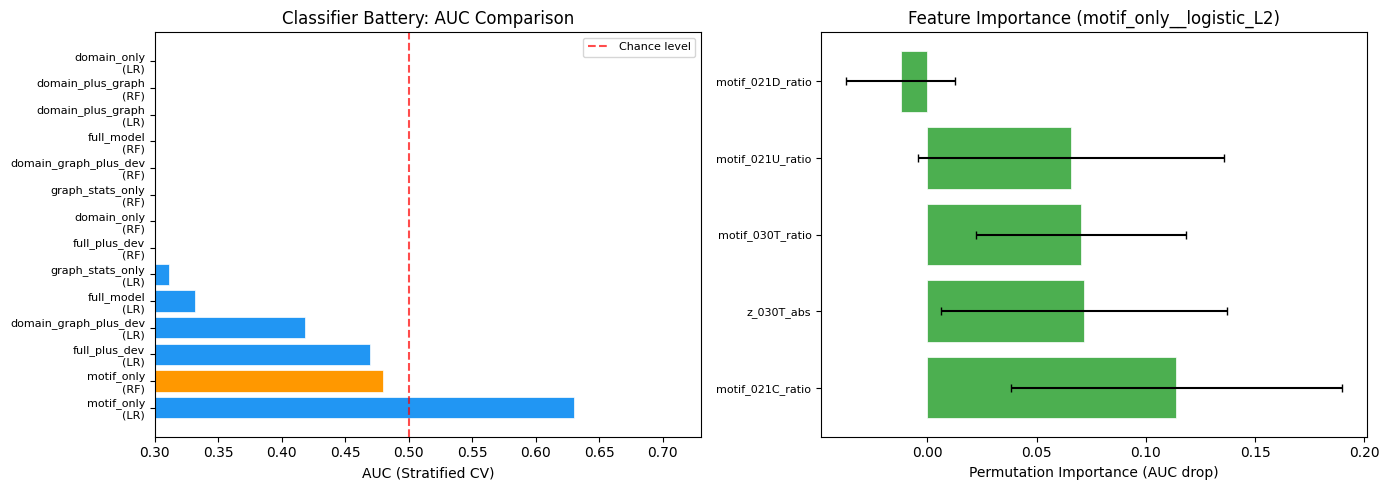


Figure saved to results_summary.png


In [13]:
# ── Results Summary Table ──
print("=" * 70)
print("CLASSIFIER RESULTS SUMMARY")
print("=" * 70)
print(f"{'Model':<45} {'AUC':>7} {'Acc':>7} {'F1':>7}")
print("-" * 70)
results_compact = {}
for k, v in sorted(all_results.items(), key=lambda x: -x[1]["auc"]):
    results_compact[k] = {kk: vv for kk, vv in v.items() if kk != "predictions"}
    marker = " <-- BEST" if k == best_key else ""
    print(f"  {k:<43} {v['auc']:>7.4f} {v['accuracy']:>7.4f} {v['f1']:>7.4f}{marker}")
print("-" * 70)

# ── Figure 1: AUC comparison bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AUC by model
model_names = list(results_compact.keys())
aucs = [results_compact[k]["auc"] for k in model_names]
colors = ['#2196F3' if 'logistic' in k else '#FF9800' for k in model_names]
short_names = [k.replace("__logistic_L2", "\n(LR)").replace("__random_forest", "\n(RF)") for k in model_names]

bars = axes[0].barh(range(len(aucs)), aucs, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(aucs)))
axes[0].set_yticklabels(short_names, fontsize=8)
axes[0].set_xlabel("AUC (Stratified CV)")
axes[0].set_title("Classifier Battery: AUC Comparison")
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Chance level')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.3, max(aucs) + 0.1)

# Right: Feature importance (top 8)
top_feats = sorted_imp[:8]
feat_names = [f[0] for f in top_feats]
feat_vals = [f[1]["mean"] for f in top_feats]
feat_stds = [f[1]["std"] for f in top_feats]

axes[1].barh(range(len(feat_names)), feat_vals, xerr=feat_stds,
             color='#4CAF50', edgecolor='white', linewidth=0.5, capsize=3)
axes[1].set_yticks(range(len(feat_names)))
axes[1].set_yticklabels(feat_names, fontsize=8)
axes[1].set_xlabel("Permutation Importance (AUC drop)")
axes[1].set_title(f"Feature Importance ({best_key})")

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("\nFigure saved to results_summary.png")